In [1]:
# Correlation analysis: load the cleaned feature table and explore relationships
# between features. Reads the CSV produced by the earlier notebooks; computes
# nothing from images. Figures are saved to Drive.
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import drive

drive.mount('/content/drive')

# Paths on Drive.
OUTPUT_ROOT = "/content/drive/MyDrive/perception-difficulty-dve/results"
TABLES_DIR = os.path.join(OUTPUT_ROOT, "tables")
FIGURES_DIR = os.path.join(OUTPUT_ROOT, "figures")
os.makedirs(FIGURES_DIR, exist_ok=True)

# Load the cleaned analysis set.
clean = pd.read_csv(os.path.join(TABLES_DIR, "features_RTTS_clean.csv"))
feature_columns = [c for c in clean.columns if c.endswith("_score")]

print(f"Loaded clean set: {len(clean)} images, {len(feature_columns)} features")
print(feature_columns)

Mounted at /content/drive
Loaded clean set: 4245 images, 8 features
['brightness_score', 'colourfulness_score', 'contrast_score', 'dark_channel_score', 'entropy_score', 'noise_score', 'saturation_score', 'sharpness_score']


Spearman correlation between features:
                     brightness_score  colourfulness_score  contrast_score  dark_channel_score  entropy_score  noise_score  saturation_score  sharpness_score
brightness_score                 1.00                 0.06           -0.03                0.82          -0.18        -0.02             -0.16             0.01
colourfulness_score              0.06                 1.00            0.21               -0.35           0.26         0.30              0.83             0.29
contrast_score                  -0.03                 0.21            1.00               -0.13           0.73         0.25              0.30             0.32
dark_channel_score               0.82                -0.35           -0.13                1.00          -0.32        -0.31             -0.54            -0.26
entropy_score                   -0.18                 0.26            0.73               -0.32           1.00         0.35              0.33             0.34
noise_score  

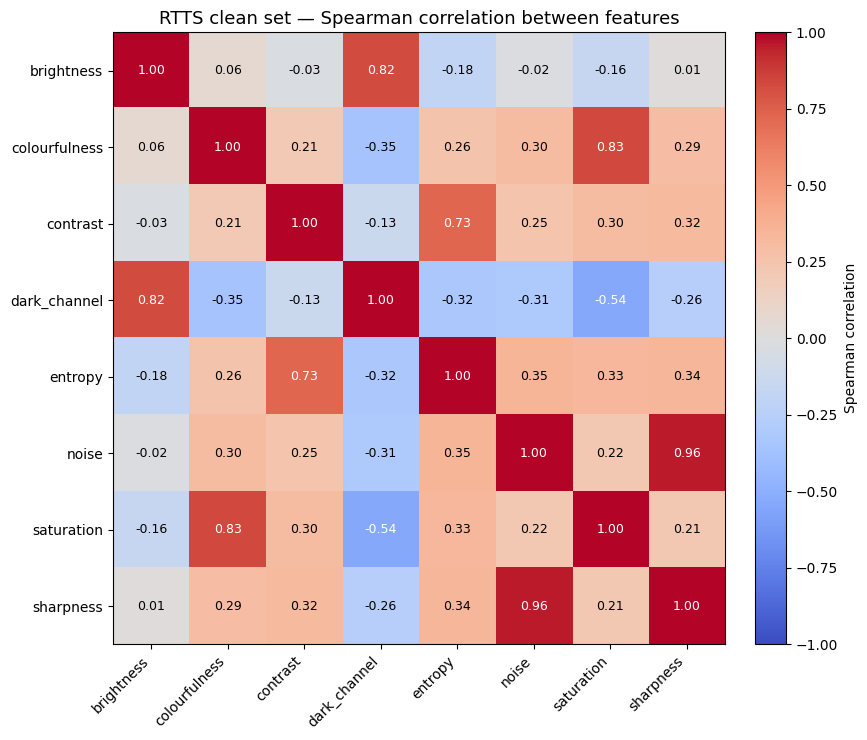

In [2]:
# Spearman correlation between the eight features.
# Shows which features move together (redundant) and which are independent.
correlation = clean[feature_columns].corr(method="spearman")

print("Spearman correlation between features:")
print(correlation.round(2).to_string())

short_names = [c.replace("_score", "") for c in feature_columns]
fig, ax = plt.subplots(figsize=(9, 7.5))
im = ax.imshow(correlation.values, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(short_names)))
ax.set_yticks(range(len(short_names)))
ax.set_xticklabels(short_names, rotation=45, ha="right", fontsize=10)
ax.set_yticklabels(short_names, fontsize=10)
for i in range(len(short_names)):
    for j in range(len(short_names)):
        value = correlation.values[i, j]
        ax.text(j, i, f"{value:.2f}", ha="center", va="center",
                color="white" if abs(value) > 0.5 else "black", fontsize=9)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Spearman correlation")
ax.set_title("RTTS clean set — Spearman correlation between features", fontsize=13)
plt.tight_layout()

figure_path = os.path.join(FIGURES_DIR, "fig_06_feature_correlation_RTTS.jpg")
plt.savefig(figure_path, dpi=110, format="jpg", bbox_inches="tight")
print("Saved figure:", figure_path)
plt.show()

## What the feature correlation shows

The eight features were correlated against each other (Spearman, on the 4,245-image
clean set) to see which measure the same thing and which are independent. This
matters because the argument for combining cues only holds if the cues actually
carry different information. Four findings stand out.

1. Two pairs are strongly redundant. Noise and sharpness correlate at 0.96 — almost
perfectly — because both react to fine high-frequency detail; on this data they are
essentially the same signal, and carrying both adds little. Saturation and
colourfulness correlate at 0.83: they overlap heavily (both drop as colour drains in
fog) but are not identical. That remaining difference is exactly the orange-haze case
found earlier — high saturation but lower colourfulness when a scene is flooded by a
single coloured light.

2. The dark channel and brightness are strongly entangled (0.82). This is the night
confound expressed as a number: the dark-channel score rises with image brightness,
so brighter images read as foggier and darker images as clearer — the exact failure
seen in night scenes, which the dark channel scores as clear. A large part of what
the dark-channel score reflects is simply how bright the image is, not how foggy.

3. Contrast and entropy are related (0.73). Both capture how much variation and detail
a scene holds, and fog flattens both. They overlap but each still adds something.

4. Several features are genuinely independent. Brightness is close to zero correlation
with contrast, colourfulness, and noise, so it carries information none of those do —
which is why it is useful as a flag for the night condition.

Overall, the eight features collapse into roughly four independent groups:
brightness with dark channel (illumination and haze, entangled); saturation with
colourfulness (colour); contrast with entropy (detail and richness); and noise with
sharpness (fine high-frequency detail, nearly identical). So there are about four
distinct signals, not eight. This is the basis for combining cues: mixing cues from
different groups adds information, while mixing within a group does not — and one of
the near-identical pair (noise or sharpness) could be dropped with little loss. It
also quantifies the dark channel's contamination by illumination, supporting the
finding that it is not a clean fog measure on its own.

Spearman rho = 0.823, p = 0.00e+00
Saved figure: /content/drive/MyDrive/perception-difficulty-dve/results/figures/fig_07_darkchannel_vs_brightness_RTTS.jpg


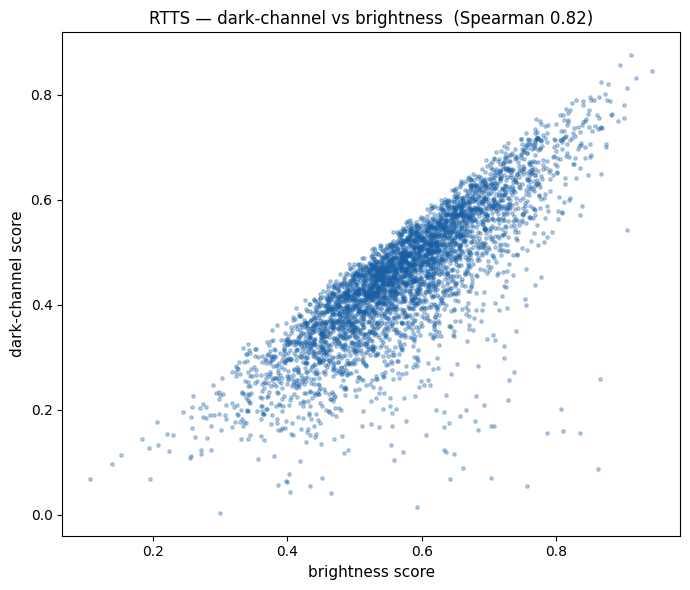

In [3]:
# Scatter: dark-channel score vs brightness, to visualise their entanglement
# (Spearman 0.82). Each point is one image. The upward trend is the night
# confound: brighter images score foggier, darker images score clearer.
from scipy.stats import spearmanr

rho, p_value = spearmanr(clean["brightness_score"], clean["dark_channel_score"])

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(clean["brightness_score"], clean["dark_channel_score"],
           s=6, alpha=0.3, color="#185FA5")
ax.set_xlabel("brightness score", fontsize=11)
ax.set_ylabel("dark-channel score", fontsize=11)
ax.set_title(f"RTTS — dark-channel vs brightness  (Spearman {rho:.2f})", fontsize=12)
plt.tight_layout()

figure_path = os.path.join(FIGURES_DIR, "fig_07_darkchannel_vs_brightness_RTTS.jpg")
plt.savefig(figure_path, dpi=110, format="jpg", bbox_inches="tight")
print(f"Spearman rho = {rho:.3f}, p = {p_value:.2e}")
print("Saved figure:", figure_path)
plt.show()

Saved figure: /content/drive/MyDrive/perception-difficulty-dve/results/figures/fig_08_darkchannel_brightness_saturation_RTTS.jpg


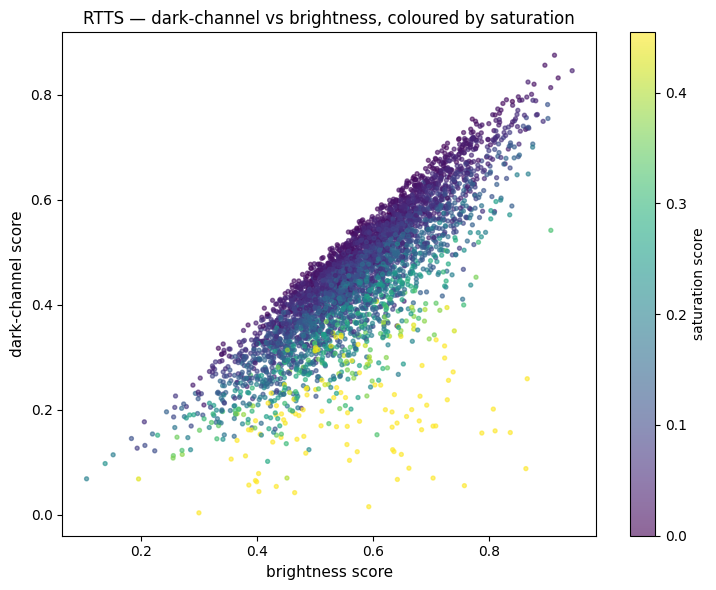

In [4]:
# Dark-channel vs brightness, each point coloured by its saturation.
# Tests whether the off-trend points (bright but low dark-channel) are the
# high-saturation orange-haze scenes, linking two confounds in one figure.
fig, ax = plt.subplots(figsize=(7.5, 6))
scatter = ax.scatter(clean["brightness_score"], clean["dark_channel_score"],
                     c=clean["saturation_score"], cmap="viridis",
                     s=8, alpha=0.6, vmin=0, vmax=clean["saturation_score"].quantile(0.98))
ax.set_xlabel("brightness score", fontsize=11)
ax.set_ylabel("dark-channel score", fontsize=11)
ax.set_title("RTTS — dark-channel vs brightness, coloured by saturation", fontsize=12)
fig.colorbar(scatter, ax=ax, label="saturation score")
plt.tight_layout()

figure_path = os.path.join(FIGURES_DIR, "fig_08_darkchannel_brightness_saturation_RTTS.jpg")
plt.savefig(figure_path, dpi=110, format="jpg", bbox_inches="tight")
print("Saved figure:", figure_path)
plt.show()

## The dark channel's failures are the coloured scenes

Colouring the dark-channel vs brightness scatter by saturation links two confounds
in one picture. The main diagonal cloud — images that follow the expected
relationship — is low saturation (greyish fog). The points that fall off the trend,
bright images scored as low dark-channel ("clear"), are high saturation. These are
the brightly coloured scenes (such as orange-lit haze). So the dark channel
under-reads fog precisely when the scene is bright and vividly coloured: the
brightness confound and the colour confound are not separate problems but the same
images. The dark channel is least trustworthy exactly where the scene carries strong
colour.